In [1]:
import os

import numpy as np
import pandas as pd
import pyBigWig
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

In [2]:
NOTEBOOK_DIR = os.getcwd()
REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

RESULTS = os.path.join(REPO_ROOT, "results")
MY_BIGWIG = os.path.join(RESULTS, "pseudobulk", "bigwig")
AUTHORS_BIGWIG = os.path.join(RESULTS, "authors_bigwig")
COMPARISON = os.path.join(RESULTS, "comparison")
FIGURES = os.path.join(RESULTS, "figures")
os.makedirs(FIGURES, exist_ok=True)

MY_MICROGLIA = os.path.join(MY_BIGWIG, "Microglia.bw")
AUT_MICROGLIA = os.path.join(AUTHORS_BIGWIG, "10x_v2___Micro_PVM.bw")

for name, path in [("mine", MY_MICROGLIA), ("authors", AUT_MICROGLIA)]:
    print(f"{'OK' if os.path.exists(path) else 'MISSING':8s} {name:10s} {path}")

OK       mine       /home/jovyan/work/repo/results/pseudobulk/bigwig/Microglia.bw
OK       authors    /home/jovyan/work/repo/results/authors_bigwig/10x_v2___Micro_PVM.bw


In [3]:
# Bin-by-bin comparison of the two microglia tracks, using the matrix
# already computed with multiBigwigSummary (5 kb bins, genome-wide).
matrix = np.load(os.path.join(COMPARISON, "matrix.npz"))
labels = [l.decode() if isinstance(l, bytes) else str(l) for l in matrix["labels"]]
data = matrix["matrix"]

print("Labels in matrix:", labels)
print("Matrix shape:", data.shape)

Labels in matrix: ['MIO_Microglia', 'MIO_Astrocytes', 'MIO_Oligodendrocytes', 'MIO_OPC', 'MIO_Endothelial', 'AUT_Microglia', 'AUT_Astrocytes', 'AUT_Oligodendrocytes', 'AUT_OPC', 'AUT_Endothelial']
Matrix shape: (545118, 10)


Bins with signal in both tracks: 458,030 of 545,118
Pearson  (log10): 0.954
Spearman (raw):   0.737


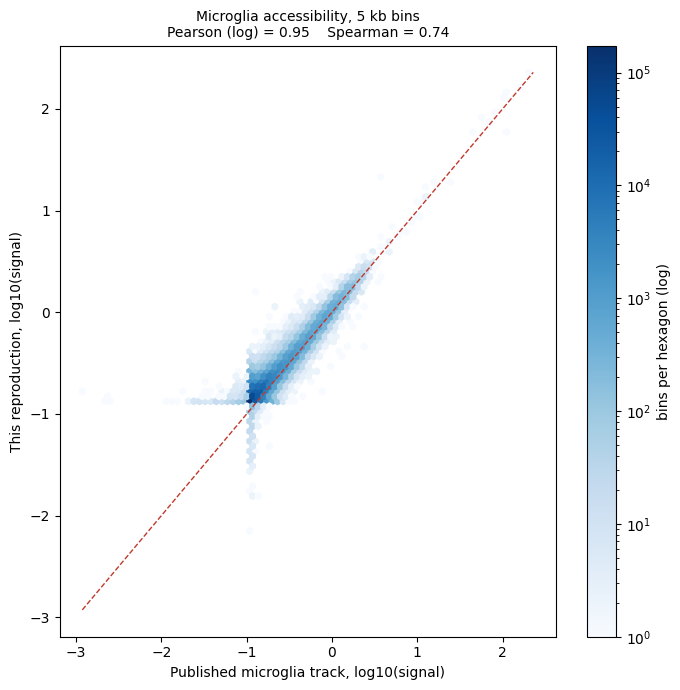

In [4]:
idx_mine = labels.index("MIO_Microglia")
idx_theirs = labels.index("AUT_Microglia")

x = data[:, idx_theirs]
y = data[:, idx_mine]

# Keep only bins with signal in both tracks: bins that are zero in both
# carry no information about agreement and would dominate the statistics.
mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
x_f, y_f = x[mask], y[mask]

log_x, log_y = np.log10(x_f), np.log10(y_f)

pearson_log, _ = pearsonr(log_x, log_y)
spearman_raw, _ = spearmanr(x_f, y_f)

print(f"Bins with signal in both tracks: {mask.sum():,} of {len(x):,}")
print(f"Pearson  (log10): {pearson_log:.3f}")
print(f"Spearman (raw):   {spearman_raw:.3f}")

fig, ax = plt.subplots(figsize=(7, 7))
hb = ax.hexbin(log_x, log_y, gridsize=80, cmap="Blues", bins="log", mincnt=1)
lims = [min(log_x.min(), log_y.min()), max(log_x.max(), log_y.max())]
ax.plot(lims, lims, color="#c0392b", linewidth=1, linestyle="--")
ax.set_xlabel("Published microglia track, log10(signal)")
ax.set_ylabel("This reproduction, log10(signal)")
ax.set_title(
    f"Microglia accessibility, 5 kb bins\n"
    f"Pearson (log) = {pearson_log:.2f}    Spearman = {spearman_raw:.2f}",
    fontsize=10,
)
fig.colorbar(hb, ax=ax, label="bins per hexagon (log)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "microglia_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

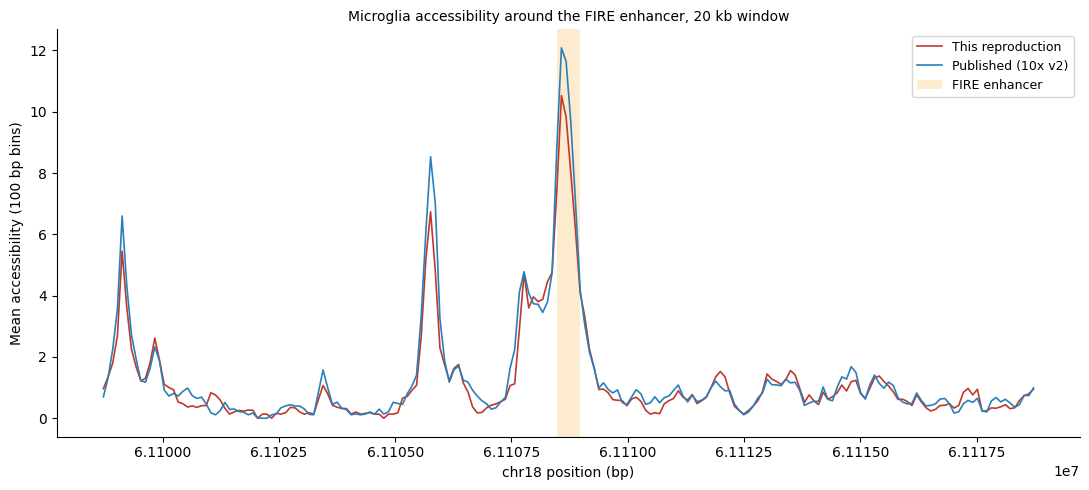

In [5]:
fire_chrom, fire_start, fire_end = "chr18", 61108475, 61108975
window = 10000
prof_start = (fire_start + fire_end) // 2 - window
prof_end = (fire_start + fire_end) // 2 + window
n_bins = (prof_end - prof_start) // 100  # 100 bp bins


def binned_signal(path, chrom, start, end, n_bins):
    bw = pyBigWig.open(path)
    values = np.array(bw.stats(chrom, start, end, nBins=n_bins, type="mean"), dtype=float)
    bw.close()
    return np.nan_to_num(values, nan=0.0)


mine_prof = binned_signal(MY_MICROGLIA, fire_chrom, prof_start, prof_end, n_bins)
theirs_prof = binned_signal(AUT_MICROGLIA, fire_chrom, prof_start, prof_end, n_bins)
positions = np.linspace(prof_start, prof_end, n_bins)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(positions, mine_prof, color="#c0392b", linewidth=1.2, label="This reproduction")
ax.plot(positions, theirs_prof, color="#2980b9", linewidth=1.2, label="Published (10x v2)")
ax.axvspan(fire_start, fire_end, color="#f39c12", alpha=0.20, linewidth=0, label="FIRE enhancer")
ax.set_xlabel(f"{fire_chrom} position (bp)")
ax.set_ylabel("Mean accessibility (100 bp bins)")
ax.set_title(f"Microglia accessibility around the FIRE enhancer, 20 kb window", fontsize=10)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "fire_profile_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [6]:
import subprocess

REGIONS_BED = "/home/jovyan/work/PUMATAC_dependencies/regions/V2.mm10-rDHS-Unfiltered.blacklisted.bed"

CELL_TYPE_PAIRS = {
    "Microglia": "Micro_PVM",
    "Astrocytes": "Astro",
    "Oligodendrocytes": "Oligo",
    "OPC": "OPC",
    "Endothelial": "Endo_VLMC",
}

files_mine = [os.path.join(MY_BIGWIG, f"{ct}.bw") for ct in CELL_TYPE_PAIRS]
files_theirs = [
    os.path.join(AUTHORS_BIGWIG, f"10x_v2___{t}.bw") for t in CELL_TYPE_PAIRS.values()
]
labels_mine = [f"MIO_{ct}" for ct in CELL_TYPE_PAIRS]
labels_theirs = [f"AUT_{ct}" for ct in CELL_TYPE_PAIRS]

matrix_rdhs = os.path.join(COMPARISON, "matrix_rdhs.npz")

cmd = [
    "multiBigwigSummary", "BED-file",
    "-b", *files_mine, *files_theirs,
    "--labels", *labels_mine, *labels_theirs,
    "--BED", REGIONS_BED,
    "-p", "8",
    "-o", matrix_rdhs,
]

print("Running multiBigwigSummary on rDHS regions (this takes several minutes)...")
result = subprocess.run(cmd, capture_output=True, text=True)
print(f"Exit code: {result.returncode}")
if result.returncode != 0:
    print(result.stderr[-2000:])
else:
    print(f"Matrix written to {matrix_rdhs}")

Running multiBigwigSummary on rDHS regions (this takes several minutes)...
Exit code: 0
Matrix written to /home/jovyan/work/repo/results/comparison/matrix_rdhs.npz


In [7]:
heatmap_rdhs = os.path.join(FIGURES, "correlation_heatmap_rdhs.png")
cormatrix_rdhs = os.path.join(COMPARISON, "correlation_matrix_rdhs.tsv")

cmd = [
    "plotCorrelation",
    "-in", matrix_rdhs,
    "--corMethod", "spearman",
    "--whatToPlot", "heatmap",
    "--plotNumbers",
    "--skipZeros",
    "--colorMap", "viridis",
    "--plotTitle", "Spearman correlation (candidate regulatory regions)",
    "-o", heatmap_rdhs,
    "--outFileCorMatrix", cormatrix_rdhs,
]

result = subprocess.run(cmd, capture_output=True, text=True)
print(f"Exit code: {result.returncode}")
if result.returncode != 0:
    print(result.stderr[-2000:])

# Compare homologous-pair correlations between the two region sets
def load_cormatrix(path):
    m = pd.read_csv(path, sep="\t", skiprows=1, index_col=0)
    m.index = [i.strip("'") for i in m.index]
    m.columns = [c.strip("'") for c in m.columns]
    return m

genome_wide = load_cormatrix(os.path.join(COMPARISON, "correlation_matrix.tsv"))
rdhs = load_cormatrix(cormatrix_rdhs)

print("\nHomologous pairs: genome-wide bins vs candidate regulatory regions")
print("-" * 68)
print(f"{'Cell type':22s} {'genome-wide':>12s} {'rDHS':>8s} {'difference':>12s}")
for ct in CELL_TYPE_PAIRS:
    gw = genome_wide.loc[f"MIO_{ct}", f"AUT_{ct}"]
    rd = rdhs.loc[f"MIO_{ct}", f"AUT_{ct}"]
    print(f"{ct:22s} {gw:12.3f} {rd:8.3f} {rd - gw:+12.3f}")
    

Exit code: 0

Homologous pairs: genome-wide bins vs candidate regulatory regions
--------------------------------------------------------------------
Cell type               genome-wide     rDHS   difference
Microglia                     0.815    0.942       +0.127
Astrocytes                    0.905    0.979       +0.073
Oligodendrocytes              0.802    0.928       +0.126
OPC                           0.778    0.927       +0.148
Endothelial                   0.565    0.842       +0.277


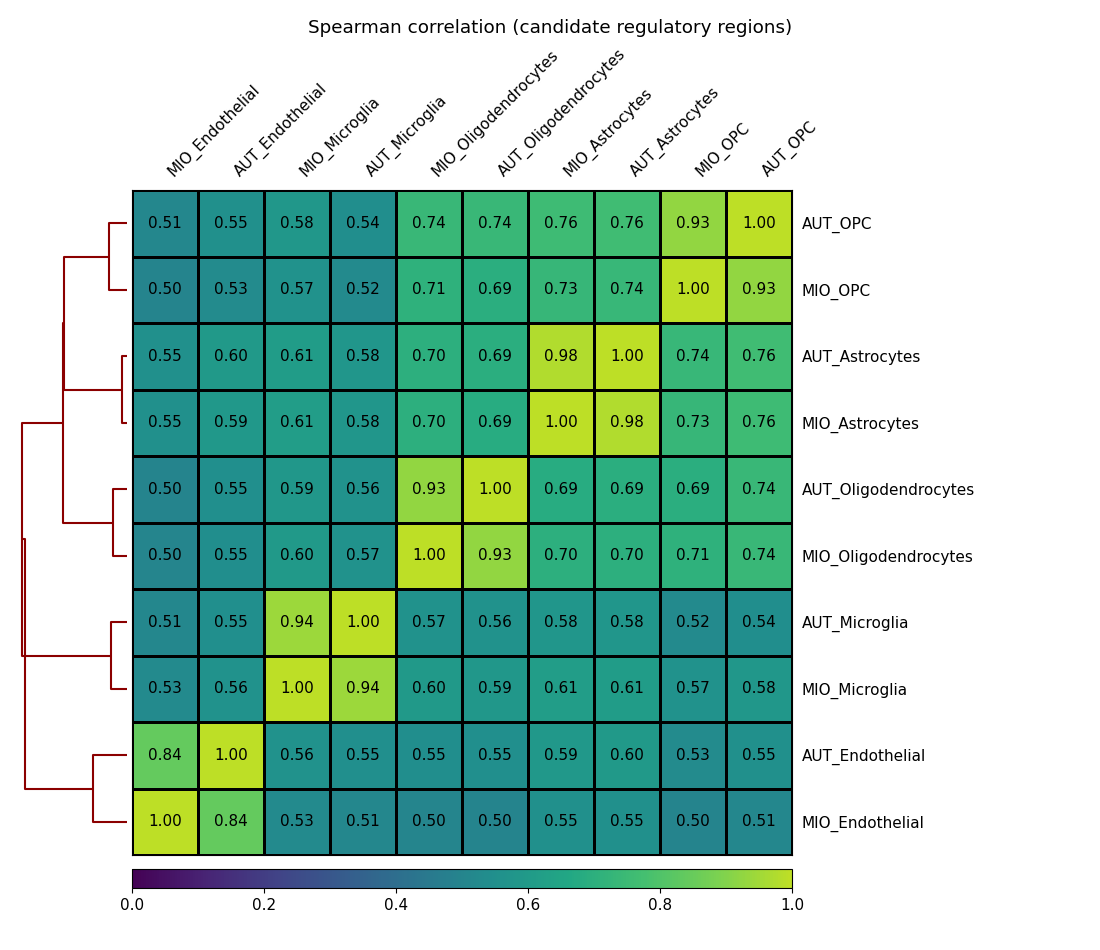

In [8]:
from IPython.display import Image
Image(heatmap_rdhs)


In [9]:
import zipfile
import urllib.request

AUTHORS_REGIONS = os.path.join(RESULTS, "authors_regions")
os.makedirs(AUTHORS_REGIONS, exist_ok=True)

# Consensus regions published by the authors on Zenodo. Each region is
# annotated in column 4 with the cell type whose peaks contributed to it,
# which allows extracting a microglia-specific set. The per-cell-type BED
# files used in the authors' own notebooks are not publicly deposited: they
# are referenced through absolute paths on their institutional cluster.
ZENODO_URL = "https://zenodo.org/records/16569439/files/regions.zip"
zip_path = os.path.join(AUTHORS_REGIONS, "regions.zip")
consensus_bed = os.path.join(
    AUTHORS_REGIONS, "regions",
    "consensus_regions_mouse_cleanup_annot_all_data_fulldepth.bed",
)

if not os.path.exists(consensus_bed):
    if not os.path.exists(zip_path):
        print("Downloading consensus regions from Zenodo...")
        urllib.request.urlretrieve(ZENODO_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(AUTHORS_REGIONS)

n_regions = sum(1 for _ in open(consensus_bed))
print(f"Consensus regions: {n_regions:,}")
with open(consensus_bed) as f:
    for _ in range(3):
        print(" ", f.readline().rstrip())

Consensus regions: 808,845
  chr1	3094286	3094786	Pvalb_peak_1a	1.4677520423432686	.
  chr1	3097001	3097501	Sst_peak_2,Sst_peak_3	2.5962293770818174	.
  chr1	3097804	3098304	Endo_VLMC_peak_1	2.1985106962838086	.


In [10]:
JACCARD_DIR = os.path.join(RESULTS, "jaccard")
os.makedirs(JACCARD_DIR, exist_ok=True)

MY_PEAKS = os.path.join(RESULTS, "macs2", "Microglia_peaks.narrowPeak")
mine_bed = os.path.join(JACCARD_DIR, "my_microglia.bed")
theirs_bed = os.path.join(JACCARD_DIR, "authors_microglia.bed")

# Both sets are restricted to the main chromosomes: scaffolds use GenBank
# names in one set and UCSC names in the other, and carry no relevant signal.
MAIN_CHROMS = {f"chr{i}" for i in range(1, 20)} | {"chrX", "chrY"}


def write_sorted_bed(records, path):
    records = sorted(records, key=lambda r: (r[0], r[1]))
    with open(path, "w") as f:
        for chrom, start, end in records:
            f.write(f"{chrom}\t{start}\t{end}\n")
    return len(records)


mine = [
    (p[0], int(p[1]), int(p[2]))
    for p in (line.split("\t") for line in open(MY_PEAKS))
    if p[0] in MAIN_CHROMS
]
theirs = [
    (p[0], int(p[1]), int(p[2]))
    for p in (line.split("\t") for line in open(consensus_bed))
    if p[0] in MAIN_CHROMS and "Micro_PVM" in p[3]
]

print(f"This reproduction: {write_sorted_bed(mine, mine_bed):,} peaks")
print(f"Published (microglia-annotated consensus): {write_sorted_bed(theirs, theirs_bed):,} regions")

This reproduction: 89,367 peaks
Published (microglia-annotated consensus): 157,016 regions


In [11]:
def run_bedtools(args):
    result = subprocess.run(args, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(result.stderr)
    return result.stdout


# Symmetric Jaccard index
jaccard_out = run_bedtools(["bedtools", "jaccard", "-a", mine_bed, "-b", theirs_bed])
header, values = jaccard_out.strip().split("\n")
jaccard_stats = dict(zip(header.split("\t"), values.split("\t")))

# Directional coverage: the biologically meaningful question is not
# symmetric. The two sets differ in nature (variable-width MACS2 peaks
# against fixed 500 bp consensus regions) and in depth (a single sample
# against an integrated multi-sample atlas), so overlap is reported in
# both directions separately.
mine_in_theirs = len(
    run_bedtools(["bedtools", "intersect", "-a", mine_bed, "-b", theirs_bed, "-u"]).splitlines()
)
theirs_in_mine = len(
    run_bedtools(["bedtools", "intersect", "-a", theirs_bed, "-b", mine_bed, "-u"]).splitlines()
)

n_mine, n_theirs = len(mine), len(theirs)

# Base-pair level overlap
bp_mine = sum(end - start for _, start, end in mine)
intersect_lines = run_bedtools(["bedtools", "intersect", "-a", mine_bed, "-b", theirs_bed]).splitlines()
bp_overlap = sum(
    int(parts[2]) - int(parts[1]) for parts in (l.split("\t") for l in intersect_lines)
)

print("Microglia peaks: this reproduction vs published consensus")
print("-" * 62)
print(f"Jaccard index (symmetric):   {float(jaccard_stats['jaccard']):.3f}")
print()
print(f"Peaks of this reproduction:  {n_mine:,}")
print(f"  overlapping published:     {mine_in_theirs:,} ({mine_in_theirs/n_mine*100:.1f}%)")
print()
print(f"Published regions:           {n_theirs:,}")
print(f"  overlapping this run:      {theirs_in_mine:,} ({theirs_in_mine/n_theirs*100:.1f}%)")
print()
print(f"Base pairs in peaks:         {bp_mine/1e6:.1f} Mb")
print(f"  within published regions:  {bp_overlap/1e6:.1f} Mb ({bp_overlap/bp_mine*100:.1f}%)")

Microglia peaks: this reproduction vs published consensus
--------------------------------------------------------------
Jaccard index (symmetric):   0.315

Peaks of this reproduction:  89,367
  overlapping published:     79,505 (89.0%)

Published regions:           157,016
  overlapping this run:      83,223 (53.0%)

Base pairs in peaks:         87.6 Mb
  within published regions:  54.5 Mb (62.2%)
